In [15]:
import importlib
import run_simulation
importlib.reload(run_simulation)
from run_simulation import run_multiple_simulations, print_statistics
import numpy as np

# --- Global run controls ---
NUM_PERMITS = 6571
N_RUNS = 100
BASE_SEED = 42
SIMULATION_DURATION = None
COLLECT_PERMITS = True

# --- Scenario parameters (all supported run_simulation knobs) ---
SCENARIO_PARAMS = {
    "name": "balanced_standard",  # label for results / utilization dict keys only
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "ai_review": "none",       # "none", "initial_check", "full_review"
    "permit_mix": "balanced",
    "pre_application_distribution": "baseline",  # baseline, lognormal_180, lognormal_60, lognormal_10, poisson_10
    "review_duration_families": None,             # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,          # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 20,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 30,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 10,
    "fire_caseload_per_staff": 7,
}

print(
    f"Running {N_RUNS} simulations ({NUM_PERMITS} permits each, "
    f"collect_permits={COLLECT_PERMITS})..."
)
results, average_staff_util_by_scenario = run_multiple_simulations(
    n_runs=N_RUNS,
    num_permits=NUM_PERMITS,
    simulation_duration=SIMULATION_DURATION,
    base_seed=BASE_SEED,
    scenario_params_list=[SCENARIO_PARAMS],
    collect_permits=COLLECT_PERMITS,
    collect_average_staff_utilization=True,
    utilization_kind="implied",
    utilization_step=0.05,
)

AVERAGE_STAFF_UTIL = average_staff_util_by_scenario[SCENARIO_PARAMS["name"]]
print(
    f"Mean staff utilization series: {AVERAGE_STAFF_UTIL['n_runs']} runs, "
    f"max day {AVERAGE_STAFF_UTIL['max_day']}, "
    f"{len(AVERAGE_STAFF_UTIL['days'])} samples."
)

results_runs = results

run_mean_total = np.array(
    [r["stats"]["average_total_time"]["mean"] for r in results_runs],
    dtype=float,
)
run_median_total = np.array(
    [r["stats"]["average_total_time"]["median"] for r in results_runs],
    dtype=float,
)

print(f"\nAcross {N_RUNS} runs — per-run mean total time (disaster -> construction):")
print(f"  Mean:    {run_mean_total.mean():.2f} days")
print(f"  Median:  {np.median(run_mean_total):.2f} days")
print(f"  Std dev: {run_mean_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_mean_total.min():.2f} days")
print(f"  Max:     {run_mean_total.max():.2f} days")

print(f"\nAcross {N_RUNS} runs — per-run median total time:")
print(f"  Mean:    {run_median_total.mean():.2f} days")
print(f"  Median:  {np.median(run_median_total):.2f} days")
print(f"  Std dev: {run_median_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_median_total.min():.2f} days")
print(f"  Max:     {run_median_total.max():.2f} days")

# All permits from all runs (for aggregate visualizations below)
all_permits = [p for r in results for p in r.get("permits", [])]

print(f"\nCollected {len(all_permits)} permit records ({N_RUNS} runs x {NUM_PERMITS} permits).")

print_statistics(results[0]["stats"])

# Debris timing summary derived from the same Monte Carlo runs above.
mean_epa_calendar_days = []
usace_phase2_span_days = []

for r in results_runs:
    perms = r.get("permits", [])
    epa_ends = [p.epa_debris_end for p in perms if p.epa_debris_end is not None]
    starts = [p.usace_debris_service_start for p in perms if p.usace_debris_service_start is not None]
    ends = [p.usace_debris_end for p in perms if p.usace_debris_end is not None]

    if not epa_ends or not starts or not ends:
        continue

    mean_epa_calendar_days.append(float(np.mean(epa_ends)))
    usace_phase2_span_days.append(float(max(ends) - min(starts)))

if not mean_epa_calendar_days or not usace_phase2_span_days:
    raise RuntimeError(
        "Debris timing metrics unavailable. Re-run with COLLECT_PERMITS=True in the first cell."
    )

m_epa = float(np.mean(mean_epa_calendar_days))
s_epa = float(np.std(mean_epa_calendar_days, ddof=1)) if len(mean_epa_calendar_days) > 1 else 0.0
m_us = float(np.mean(usace_phase2_span_days))
s_us = float(np.std(usace_phase2_span_days, ddof=1)) if len(usace_phase2_span_days) > 1 else 0.0

print("\nCohort debris timing (from the runs above):")
print(
    "1) Mean calendar days from disaster (t=0) until EPA phase 1 complete "
    "(average of epa_debris_end across properties; then mean across runs):"
)
print(
    f"   {m_epa:.2f} days"
    + (f"  (std across runs: {s_epa:.2f})" if len(mean_epa_calendar_days) > 1 else "")
)
print(
    "2) USACE phase 2 total duration: min(usace service start) -> max(usace end) "
    "(one value per run; mean across runs):"
)
print(
    f"   {m_us:.2f} days"
    + (f"  (std across runs: {s_us:.2f})" if len(usace_phase2_span_days) > 1 else "")
)



Running 100 simulations (6571 permits each, collect_permits=True)...
Mean staff utilization series: 100 runs, max day 5000, 100001 samples.

Across 100 runs — per-run mean total time (disaster -> construction):
  Mean:    620.40 days
  Median:  620.24 days
  Std dev: 6.40 days
  Min:     607.10 days
  Max:     639.97 days

Across 100 runs — per-run median total time:
  Mean:    444.65 days
  Median:  444.87 days
  Std dev: 4.17 days
  Min:     435.66 days
  Max:     456.15 days

Collected 655686 permit records (100 runs x 6571 permits).

SIMULATION STATISTICS

Total Completed Permits: 6557
Total In Progress: 14

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 1338 (20.41%)
  CUSTOM_NON_LIKE               :  313 ( 4.77%)
  PRE_APPROVED_LIKE             : 2600 (39.65%)
  PRE_APPROVED_NON_LIKE         :  660 (10.07%)
  SEL

In [16]:
# County review vs applicant time across runs
# Uses `results_runs` from the first cell.

county_means = []
county_medians = []
applicant_means = []
applicant_medians = []
county_stds = []
applicant_stds = []

definitions = []
for r in results_runs:
    cv = r["stats"].get("county_review_vs_applicant", {})
    if not cv:
        continue
    county_means.append(cv.get("county_review_mean", np.nan))
    county_medians.append(cv.get("county_review_median", np.nan))
    applicant_means.append(cv.get("applicant_mean", np.nan))
    applicant_medians.append(cv.get("applicant_median", np.nan))
    county_stds.append(cv.get("county_review_std", np.nan))
    applicant_stds.append(cv.get("applicant_std", np.nan))
    if cv.get("definition"):
        definitions.append(cv["definition"])

if not county_means:
    raise RuntimeError("No county_review_vs_applicant metrics found. Run the simulation cell first.")

county_means = np.array(county_means, dtype=float)
county_medians = np.array(county_medians, dtype=float)
applicant_means = np.array(applicant_means, dtype=float)
applicant_medians = np.array(applicant_medians, dtype=float)
county_stds = np.array(county_stds, dtype=float)
applicant_stds = np.array(applicant_stds, dtype=float)

print("Across runs — county review time (days per permit):")
print(f"  Mean of run means:   {county_means.mean():.2f}")
print(f"  Mean of run medians: {county_medians.mean():.2f}")
print(f"  Mean of run std dev: {county_stds.mean():.2f}")

print("\nAcross runs — applicant time (days per permit):")
print(f"  Mean of run means:   {applicant_means.mean():.2f}")
print(f"  Mean of run medians: {applicant_medians.mean():.2f}")
print(f"  Mean of run std dev: {applicant_stds.mean():.2f}")

if definitions:
    print("\nDefinition:")
    print(definitions[0])

Across runs — county review time (days per permit):
  Mean of run means:   33.34
  Mean of run medians: 14.15
  Mean of run std dev: 47.07

Across runs — applicant time (days per permit):
  Mean of run means:   593.03
  Mean of run medians: 419.16
  Mean of run std dev: 544.97

Definition:
County = planning + public works + fire + special zoning + agency referral (waiting + review service). Applicant = pre-application (plan prep) + applicant revisions. Debris (EPA/USACE) separate. Public works and fire overlap in 'standard' flow (double-counts calendar). 'Standard' may finish before debris completes, so sums can exceed (ready_for_construction - created_at).


In [17]:
# `results`: list of 100 run dicts (each has "stats", "permits", "seed", …).
# `all_permits`: all completed permits from all 100 runs (aggregate plots and random Gantt sampling).


In [18]:
# Debris timing now comes from the first simulation cell (no rerun needed).
if "m_epa" not in globals() or "m_us" not in globals():
    raise RuntimeError("Run the first simulation cell to populate debris timing metrics.")

print("Using debris timing metrics computed in the first cell.")
print(
    "1) Mean calendar days from disaster (t=0) until EPA phase 1 complete "
    "(average of epa_debris_end across properties; then mean across runs):"
)
print(
    f"   {m_epa:.2f} days"
    + (f"  (std across runs: {s_epa:.2f})" if len(mean_epa_calendar_days) > 1 else "")
)
print(
    "2) USACE phase 2 total duration: min(usace service start) -> max(usace end) "
    "(one value per run; mean across runs):"
)
print(
    f"   {m_us:.2f} days"
    + (f"  (std across runs: {s_us:.2f})" if len(usace_phase2_span_days) > 1 else "")
)


Using debris timing metrics computed in the first cell.
1) Mean calendar days from disaster (t=0) until EPA phase 1 complete (average of epa_debris_end across properties; then mean across runs):
   54.02 days  (std across runs: 0.33)
2) USACE phase 2 total duration: min(usace service start) -> max(usace end) (one value per run; mean across runs):
   287.12 days  (std across runs: 3.88)


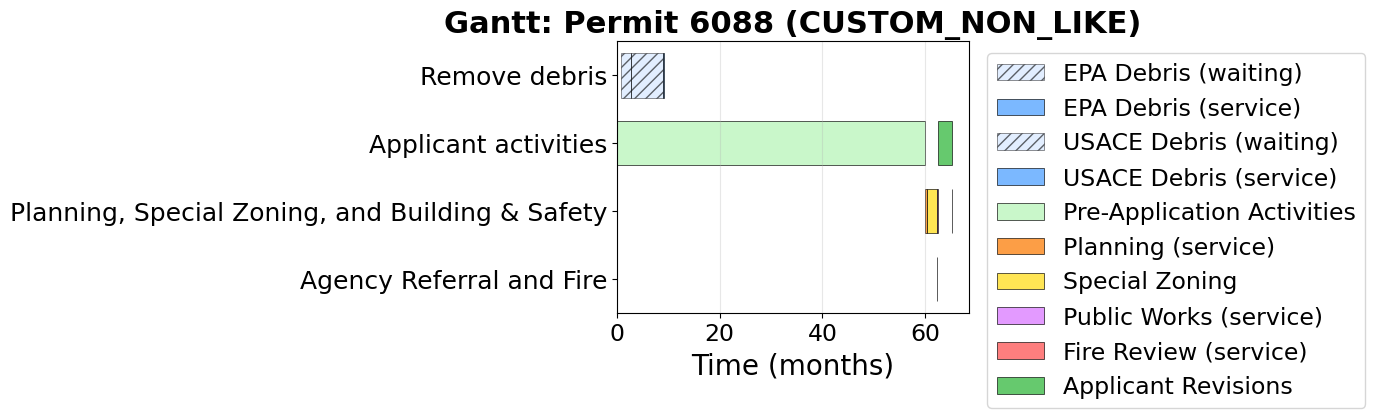

In [19]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_one_random_permit_segment
import matplotlib.pyplot as plt

fig, ax = plot_gantt_one_random_permit_segment(
    all_permits,
    segment_value=4,
    random_seed=100,
    figsize=(14, 4),
    color_option="option_1",
)
if fig:
    plt.show()

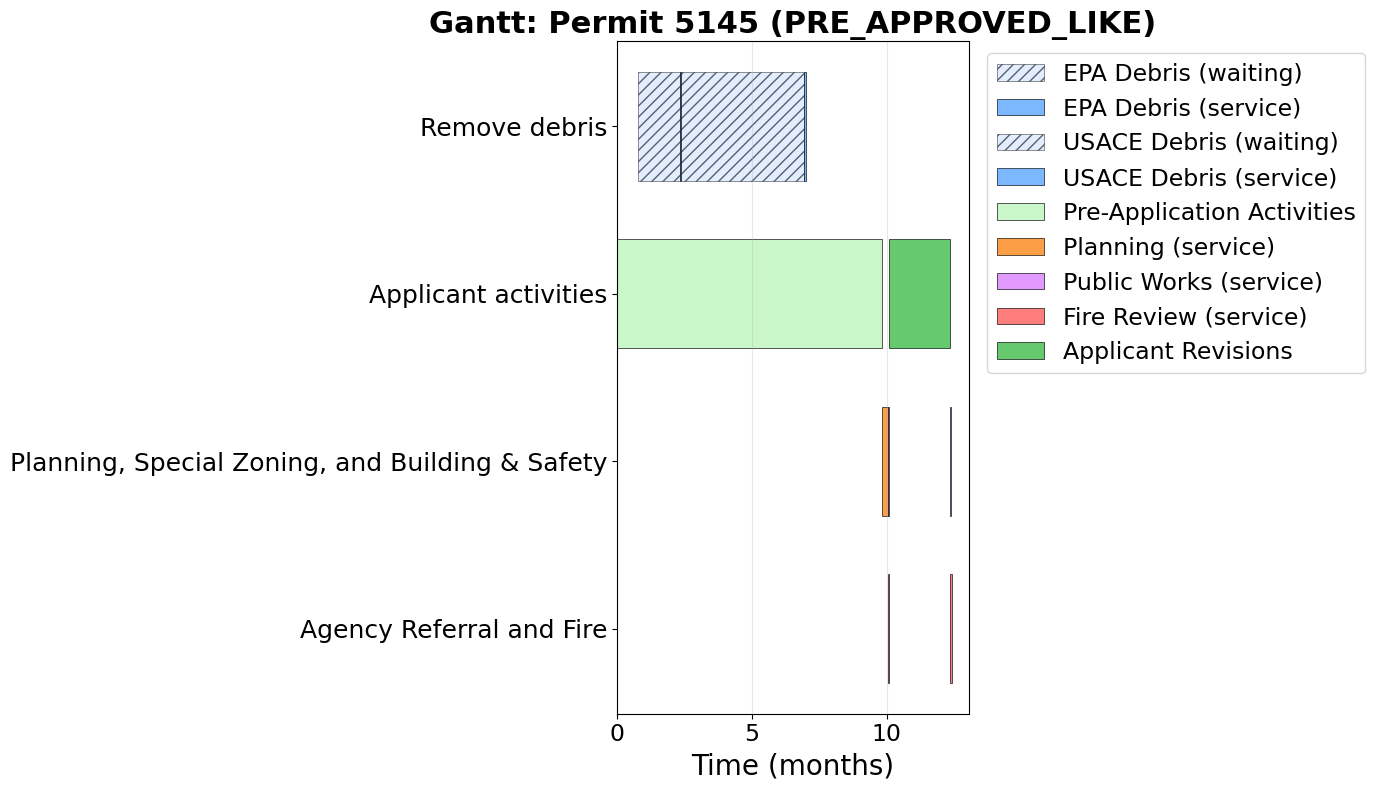

In [20]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt
import random

# One random run from the 100, same list index as before (representative Gantt)
_run = random.Random(36).choice(results)
_run_permits = _run.get("permits", [])

if not _run_permits:
    print("No permits available in selected run.")
else:
    selected_permit = random.Random(36).choice(_run_permits)
    fig, ax = plot_gantt_single_permit(
        selected_permit,
        figsize=(14, 8),
        color_option="option_1",
    )
    if fig:
        plt.show()

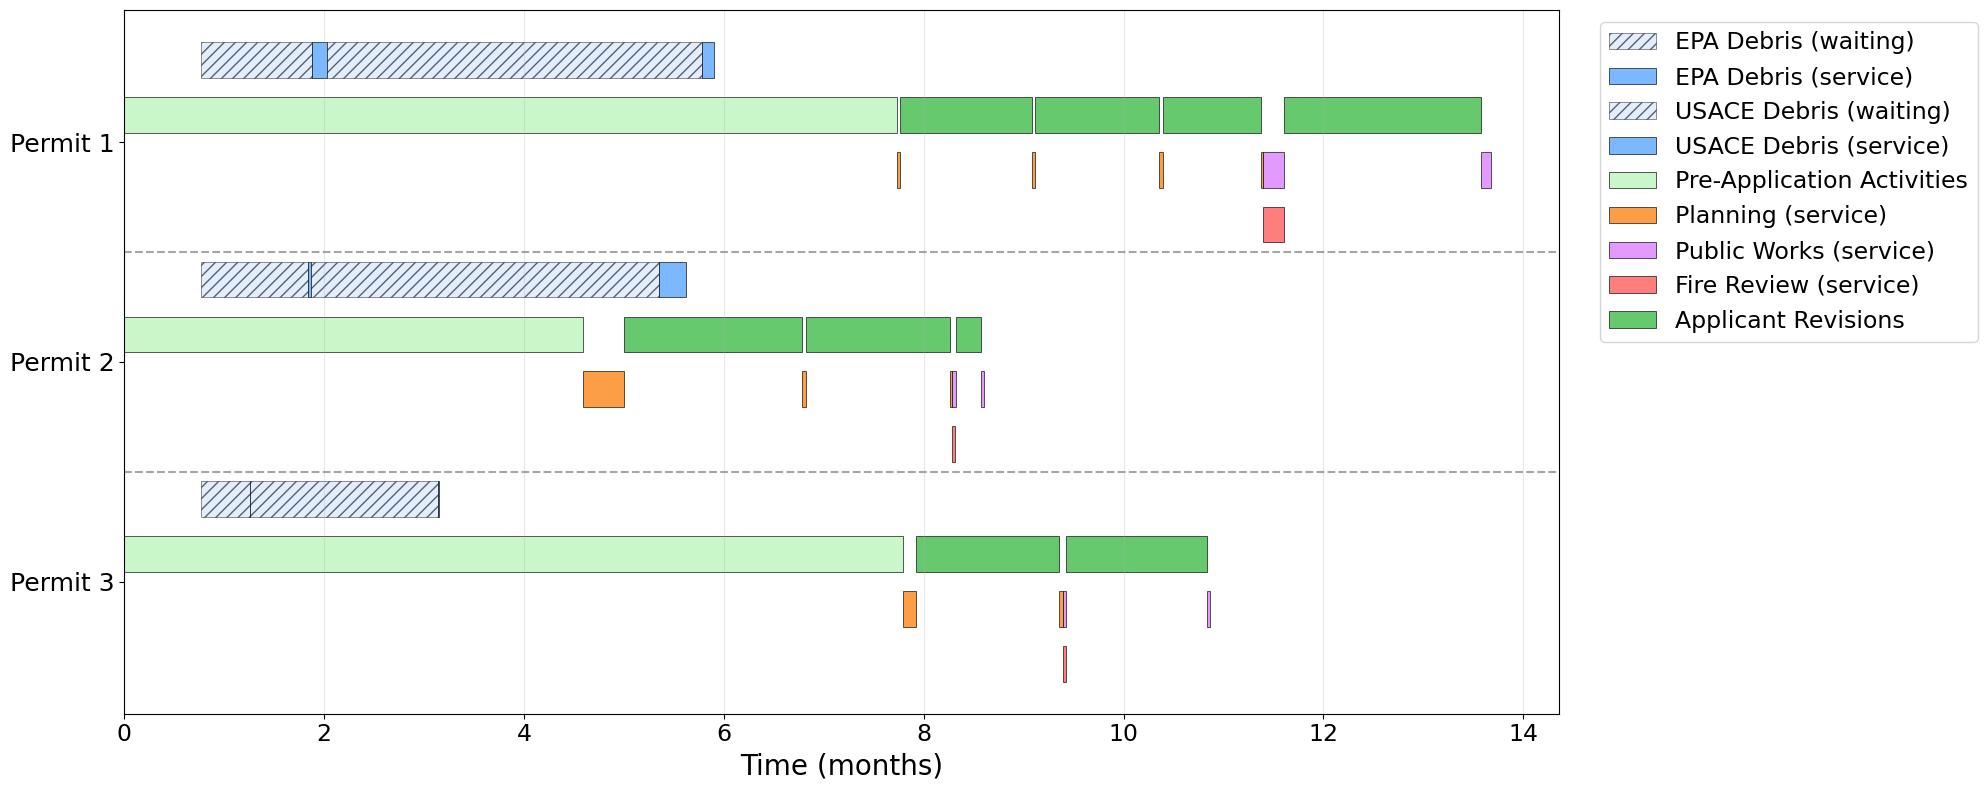

In [21]:
# Gantt chart for 3 random permits
from visualize_permits import plot_gantt_three_random_permits
import matplotlib.pyplot as plt

fig, ax = plot_gantt_three_random_permits(
    all_permits,
    random_seed=45,
    figsize=(20, 8),
    color_option="option_1",
)
if fig:
    plt.show()

Average waiting and service time by step (days):
  EPA Debris: waiting mean=29.53, σ=17.72; service mean=1.50, σ=1.22
  USACE Debris: waiting mean=99.96, σ=53.62; service mean=2.00, σ=1.41
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=498.95, σ=543.57
  Planning: waiting mean=0.00, σ=0.03; service mean=6.80, σ=2.97
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=57.53, σ=45.41
  Public Works: waiting mean=0.00, σ=0.00; service mean=3.76, σ=3.73
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=38.22, σ=30.26
  Fire Review: waiting mean=0.00, σ=0.03; service mean=3.67, σ=3.65
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=94.46, σ=40.53


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Average Total Waiting vs Service Time by Process Step'}, xlabel='Process Step', ylabel='Average Time (days)'>)

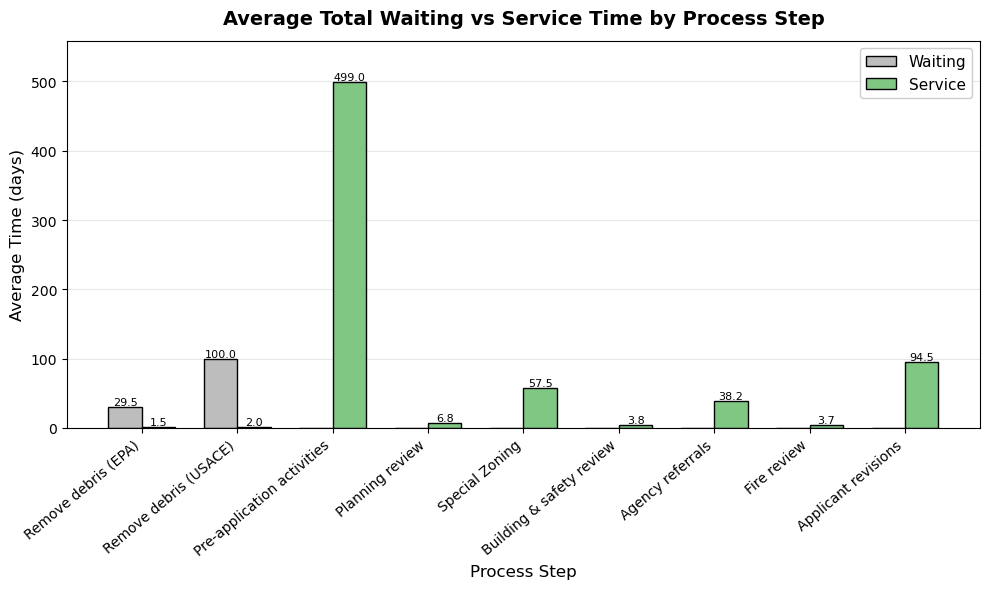

In [22]:
# Visualize the time each permit spends in each stage
from visualize_permits import plot_average_waiting_and_service_by_step


# Visualize aggregate time spent in each process stage across all runs
label_map = {
    "EPA Debris": "Remove debris (EPA)",
    "USACE Debris": "Remove debris (USACE)",
    "Pre-Application Activities": "Pre-application activities",
    "Planning": "Planning review",
    "Special Zoning Review": "Special zoning review",
    "Public Works": "Building & safety review",
    "Agency Referral": "Agency referrals",
    "Fire Review": "Fire review",
    "Applicant Revisions": "Applicant revisions",
}
plot_average_waiting_and_service_by_step(all_permits, label_map=label_map)


Calculate statistics to understand the amount of time between the end of debris removal and plan submission

In [23]:
import statistics

deltas = [
    p.plan_prep_end - p.debris_removal_end
    for p in all_permits
    if p.plan_prep_end is not None and p.debris_removal_end is not None
]

statistics.mean(deltas), statistics.median(deltas)

(342.96987611331775, 174.2710699917866)

In [24]:
# Snapshot summaries for day 415 and 474 — mean / std across Monte Carlo runs
if "results" not in globals() or "NUM_PERMITS" not in globals():
    raise ValueError("Run the first cell first.")
if not COLLECT_PERMITS:
    raise ValueError("Set COLLECT_PERMITS=True in the first cell for snapshots.")

SNAPSHOT_DAYS = [415, 478]


def done_by_day(p, attr, day):
    t = getattr(p, attr)
    return (t is not None) and (t <= day)


def snapshot_counts(perms, day):
    applications_received = [p for p in perms if p.plan_prep_end is not None and p.plan_prep_end <= day]
    issued = [p for p in perms if done_by_day(p, "planning_end", day)]
    ready = [p for p in perms if done_by_day(p, "ready_for_construction", day)]
    pw_done = [p for p in perms if done_by_day(p, "public_works_end", day)]
    fire_done = [p for p in perms if done_by_day(p, "fire_review_end", day)]

    issued_not_ready = [p for p in issued if not done_by_day(p, "ready_for_construction", day)]
    issued_pw_missing = [p for p in issued_not_ready if not done_by_day(p, "public_works_end", day)]
    issued_fire_missing = [p for p in issued_not_ready if not done_by_day(p, "fire_review_end", day)]
    issued_both_missing = [
        p
        for p in issued_not_ready
        if (not done_by_day(p, "public_works_end", day)) and (not done_by_day(p, "fire_review_end", day))
    ]
    issued_pw_done_fire_missing = [
        p
        for p in issued_not_ready
        if done_by_day(p, "public_works_end", day) and (not done_by_day(p, "fire_review_end", day))
    ]
    issued_fire_done_pw_missing = [
        p
        for p in issued_not_ready
        if done_by_day(p, "fire_review_end", day) and (not done_by_day(p, "public_works_end", day))
    ]
    return {
        "n_applications_received": len(applications_received),
        "n_issued": len(issued),
        "n_ready": len(ready),
        "n_pw": len(pw_done),
        "n_fire": len(fire_done),
        "n_issued_not_ready": len(issued_not_ready),
        "n_pw_only_gap": len(issued_fire_done_pw_missing),
        "n_fire_only_gap": len(issued_pw_done_fire_missing),
        "n_both_gap": len(issued_both_missing),
        "n_missing_pw_any": len(issued_pw_missing),
        "n_missing_fire_any": len(issued_fire_missing),
    }


for day in SNAPSHOT_DAYS:
    rows = []
    for r in results:
        perms = r.get("permits") or []
        rows.append(snapshot_counts(perms, day))

    def mean_count(key):
        vals = np.array([row[key] for row in rows], dtype=float)
        return vals.mean(), vals.std(ddof=1) if len(vals) > 1 else 0.0

    print(f"Checkpoint day: {day} (mean ± std across {len(rows)} runs, counts out of {NUM_PERMITS})")
    print("---")
    for label, key in [
        ("Rebuild applications received <= day", "n_applications_received"),
        ("Permit issued (planning_end <= day)", "n_issued"),
        ("Public Works approved <= day", "n_pw"),
        ("Fire approved <= day", "n_fire"),
        ("Ready for construction <= day", "n_ready"),
    ]:
        m, s = mean_count(key)
        print(f"{label:42s} {m:7.1f} ± {s:5.1f}")

    print("--- Issued but NOT ready (counts, mean ± std):")
    for label, key in [
        ("Total issued not ready", "n_issued_not_ready"),
        ("  Missing Public Works only", "n_pw_only_gap"),
        ("  Missing Fire only", "n_fire_only_gap"),
        ("  Missing BOTH PW and Fire", "n_both_gap"),
        ("  Missing PW (any)", "n_missing_pw_any"),
        ("  Missing Fire (any)", "n_missing_fire_any"),
    ]:
        vals = np.array([row[key] for row in rows], dtype=float)
        m, s = vals.mean(), vals.std(ddof=1) if len(vals) > 1 else 0.0
        print(f"{label:42s} {m:7.1f} ± {s:5.1f}")
    print()

Checkpoint day: 415 (mean ± std across 100 runs, counts out of 6571)
---
Rebuild applications received <= day        3956.2 ±  36.4
Permit issued (planning_end <= day)         3589.3 ±  36.3
Public Works approved <= day                3080.6 ±  36.7
Fire approved <= day                        3226.2 ±  35.4
Ready for construction <= day               3020.4 ±  35.7
--- Issued but NOT ready (counts, mean ± std):
Total issued not ready                       568.8 ±  24.8
  Missing Public Works only                  184.2 ±  15.2
  Missing Fire only                           38.6 ±   6.3
  Missing BOTH PW and Fire                   324.4 ±  18.2
  Missing PW (any)                           508.6 ±  23.2
  Missing Fire (any)                         363.0 ±  18.6

Checkpoint day: 478 (mean ± std across 100 runs, counts out of 6571)
---
Rebuild applications received <= day        4318.4 ±  35.1
Permit issued (planning_end <= day)         4016.6 ±  37.2
Public Works approved <= day           

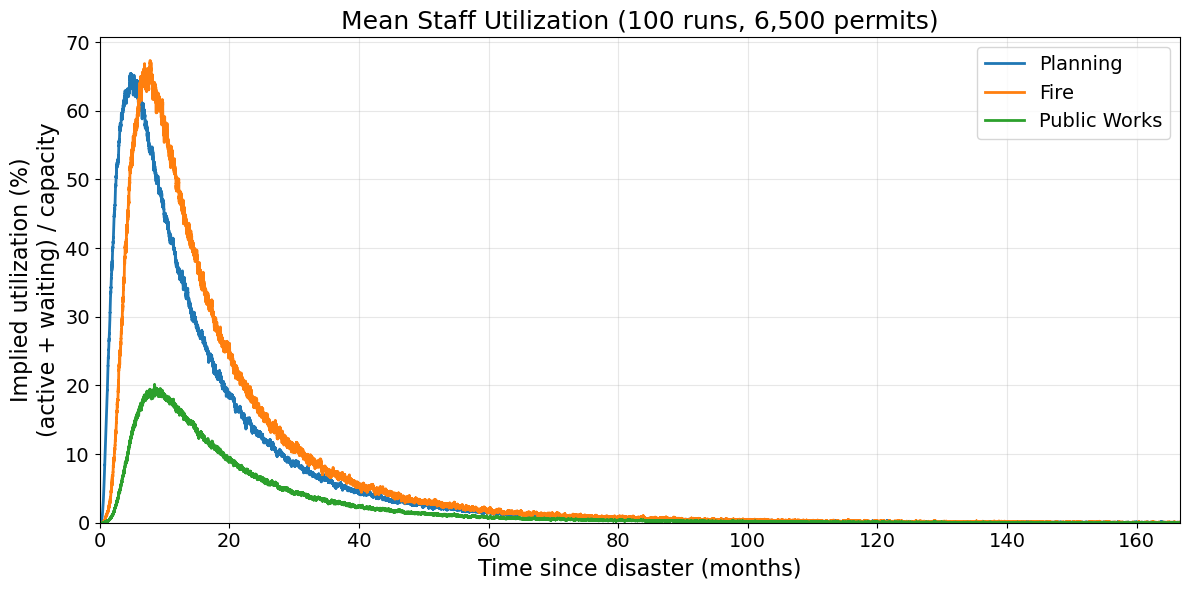

In [25]:
# Mean staff utilization (multi-run average from the first cell)
from run_simulation import plot_staff_utilization_series

if "AVERAGE_STAFF_UTIL" not in globals():
    raise RuntimeError("Run the first cell so `AVERAGE_STAFF_UTIL` exists.")

plot_staff_utilization_series(
    AVERAGE_STAFF_UTIL,
    title=f"Mean Staff Utilization ({AVERAGE_STAFF_UTIL['n_runs']} runs, 6,500 permits)",
    # xlim=(0, 800),
    # ylim=(0, 100),
)


In [26]:
# Peak mean utilization (same series as the plot above)
if "AVERAGE_STAFF_UTIL" not in globals():
    raise RuntimeError("Run the first cell so `AVERAGE_STAFF_UTIL` exists.")

u = AVERAGE_STAFF_UTIL
print("Planning peak mean (%):", 100 * max(u["planning"]))
print("Fire peak mean (%):", 100 * max(u["fire"]))
print("Public works peak mean (%):", 100 * max(u["public_works"]))
print("runs:", u["n_runs"], "max day:", u["max_day"])

Planning peak mean (%): 65.42857142857143
Fire peak mean (%): 67.32857142857144
Public works peak mean (%): 20.142857142857125
runs: 100 max day: 5000


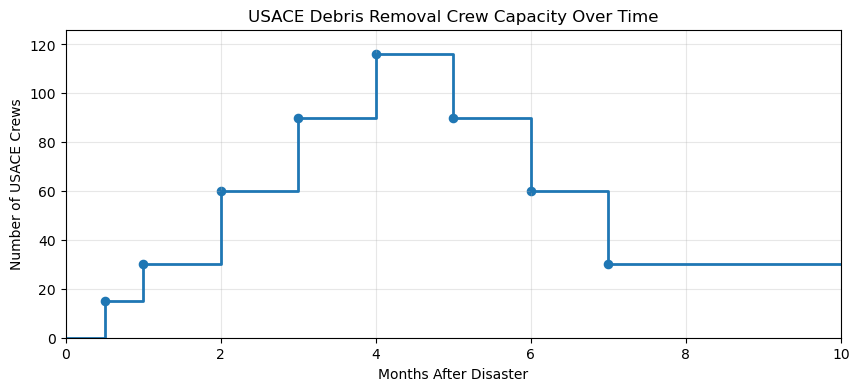

In [27]:
# USACE debris-removal crews over time (from the simulation schedule)
from permit_simulation import PermitSimulation
import matplotlib.pyplot as plt

schedule = PermitSimulation.USACE_CREW_SCHEDULE
days_per_month = 30.0
plot_end_day = 300.0
plot_end_month = plot_end_day / days_per_month

months = [0.0] + [day / days_per_month for day, _ in schedule] + [plot_end_month]
crews = [0] + [count for _, count in schedule] + [schedule[-1][1]]

plt.figure(figsize=(10, 4))
plt.step(months, crews, where="post", linewidth=2)
plt.scatter([day / days_per_month for day, _ in schedule], [count for _, count in schedule], s=35)
plt.title("USACE Debris Removal Crew Capacity Over Time")
plt.xlabel("Months After Disaster")
plt.ylabel("Number of USACE Crews")
plt.xlim(0, plot_end_month)
plt.ylim(0, max(crews) + 10)
plt.grid(alpha=0.3)
plt.show()

In [28]:
# Day-474 average county-review vs applicant-revision time (excluding pre-application)
import numpy as np
from permit_simulation import _permit_county_review_days

DAY = 478

if "results" not in globals():
    raise ValueError("Run the first cell first so `results` exists.")
if not COLLECT_PERMITS:
    raise ValueError("Set COLLECT_PERMITS=True in the first cell.")

county_run_means = []
revision_run_means = []
eligible_counts = []

for r in results:
    perms = r.get("permits") or []
    # same checkpoint denominator as your 'applications received' definition
    eligible = [p for p in perms if p.plan_prep_end is not None and p.plan_prep_end <= DAY]
    eligible_counts.append(len(eligible))

    if not eligible:
        county_run_means.append(np.nan)
        revision_run_means.append(np.nan)
        continue

    county_vals = np.array([_permit_county_review_days(p) for p in eligible], dtype=float)
    revision_vals = np.array([p.applicant_revisions_total_time for p in eligible], dtype=float)

    county_run_means.append(float(np.mean(county_vals)))
    revision_run_means.append(float(np.mean(revision_vals)))

print(f"Checkpoint day: {DAY}")
print(f"Applications received by day (mean across runs): {np.mean(eligible_counts):.1f}")
print("---")
print(
    "County review days (mean ± std across runs): "
    f"{np.nanmean(county_run_means):.2f} ± "
    f"{np.nanstd(county_run_means, ddof=1):.2f}"
)
print(
    "Applicant revision days only (mean ± std across runs): "
    f"{np.nanmean(revision_run_means):.2f} ± "
    f"{np.nanstd(revision_run_means, ddof=1):.2f}"
)


Checkpoint day: 478
Applications received by day (mean across runs): 4318.4
---
County review days (mean ± std across runs): 33.01 ± 0.78
Applicant revision days only (mean ± std across runs): 94.01 ± 0.64
